# TP02 — Mineração de Dados — Grupo 06
## Notebook 1/3 — Análise Exploratória (EDA)

**Problema B:** dado que um candidato foi convocado, ele efetivará a matrícula?

Pipeline em 3 notebooks: **(1) EDA** · (2) Pré-processamento (gera as bases tratadas) · (3) Modelagem (lê as bases e treina). Este notebook carrega a base bruta e explora os dados.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)
print("Setup OK")

Setup OK


**Decisão de carregamento.** A base é um arquivo de origem governamental com características específicas:
- separador de campos `|`;
- codificação **Latin-1** (não UTF-8) — contém acentuação (`Ç`, `Ã`...);
- **vírgula como separador decimal** (ex.: `622,5`). Sem `decimal=","`, as notas objetivas e com peso seriam lidas como texto.

In [15]:
CSV = "lista_de_espera_sisu_2023_2.csv"
df = pd.read_csv(CSV, sep="|", encoding="latin-1", decimal=",", low_memory=False)
print("Shape:", df.shape)
df.head(3)

Shape: (148773, 56)


,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,UF_CAMPUS,MUNICIPIO_CAMPUS,CODIGO_CURSO,NOME_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,PESO_L,PESO_CH,PESO_CN,PESO_M,PESO_R,NOTA_MINIMA_L,NOTA_MINIMA_CH,NOTA_MINIMA_CN,NOTA_MINIMA_M,NOTA_MINIMA_R,MEDIA_MINIMA,CPF,INSCRICAO_ENEM,INSCRITO,SEXO,DT_NASCIMENTO,UF_CANDIDATO,MUNICIPIO_CANDIDATO,OPCAO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
0,2023,2,7,LISTA DE ESPERA,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,RJ,Rio de Janeiro,1441998,SISTEMAS DE INFORMAÇÃO,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,15,NaN,1.0,1.0,2.0,4.0,3.0,453.8,444.7,453.3,438.4,300.0,418.04,XXX.398407-XX,221XXXXXX236,ALBERTH TEIXEIRA DA ROCHA,M,2001,RJ,Rio de Janeiro,2,620.3,630.2,553.2,731.6,660,620.3,630.2,1106.4,2926.4,1980,660.30,660.69,16,S,NÃO CONVOCADO
1,2023,2,7,LISTA DE ESPERA,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,RJ,Rio de Janeiro,1441998,SISTEMAS DE INFORMAÇÃO,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,15,NaN,1.0,1.0,2.0,4.0,3.0,453.8,444.7,453.3,438.4,300.0,418.04,XXX.787587-XX,221XXXXXX458,ALEXANDRE VIANA GONCALVES,M,1994,RJ,Rio de Janeiro,1,631.3,604.8,621.1,673.1,580,631.3,604.8,1242.2,2692.4,1740,628.25,660.69,27,S,NÃO CONVOCADO
2,2023,2,7,LISTA DE ESPERA,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,RJ,Rio de Janeiro,1441998,SISTEMAS DE INFORMAÇÃO,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,15,NaN,1.0,1.0,2.0,4.0,3.0,453.8,444.7,453.3,438.4,300.0,418.04,XXX.641477-XX,221XXXXXX526,ANA JULIA MELO DA SILVA,F,2004,RJ,Resende,2,534.8,550.8,468.5,612.0,820,534.8,550.8,937.0,2448.0,2460,630.05,660.69,26,S,NÃO CONVOCADO


## Etapa 1 — Análise Exploratória (EDA)

### 1.1 Inspeção inicial: tipos, faltantes e duplicatas

In [17]:
print("=== Estrutura (tipos e contagem de não-nulos) ===")
df.info()

print("\n=== Top colunas com valores faltantes ===")
faltantes = df.isna().sum().sort_values(ascending=False)
print(faltantes[faltantes > 0])

print("\n=== Colunas constantes (1 único valor) ===")
nun = df.nunique(dropna=False)
print(list(nun[nun == 1].index))

print("\n=== Duplicatas ===")
print("Linhas totalmente idênticas:", df.duplicated().sum())
print("CPFs repetidos:", df['CPF'].duplicated().sum(),
      "(esperado: um candidato pode concorrer a várias opções de curso)")

=== Estrutura (tipos e contagem de não-nulos) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148773 entries, 0 to 148772
Data columns (total 56 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ANO                    148773 non-null  int64  
 1   EDICAO                 148773 non-null  int64  
 2   ETAPA                  148773 non-null  int64  
 3   DS_ETAPA               148773 non-null  object 
 4   CODIGO_IES             148773 non-null  int64  
 5   NOME_IES               148773 non-null  object 
 6   SIGLA_IES              148773 non-null  object 
 7   UF_IES                 148773 non-null  object 
 8   CODIGO_CAMPUS          148773 non-null  int64  
 9   NOME_CAMPUS            148773 non-null  object 
 10  UF_CAMPUS              148773 non-null  object 
 11  MUNICIPIO_CAMPUS       148773 non-null  object 
 12  CODIGO_CURSO           148773 non-null  int64  
 13  NOME_CURSO             148773 non-null 

### 1.2 População e variável-alvo do Problema
A pergunta é condicionada a **ter sido convocado**. O campo `MATRICULA` codifica o desfecho:

| Status | Significado | Uso no Problema B |
|---|---|---|
| `NÃO CONVOCADO` | nunca foi chamado | **excluído** (fora da condição "foi convocado") |
| `EFETIVADA` | matrícula concluída | alvo **positivo (1)** |
| `NÃO COMPARECEU` | não se apresentou | negativo (0) |
| `DOCUMENTACAO REJEITADA` | documentação reprovada | negativo (0) |
| `CANCELADA` | matrícula cancelada | negativo (0) |
| `PENDENTE` | processo em andamento | **excluído** (desfecho ainda indefinido — rótulo ambíguo) |

**Decisão:** alvo binário `EFETIVOU` = 1 se `EFETIVADA`, 0 para os demais desfechos *resolvidos*; excluímos `PENDENTE` para não rotular como "não efetivou" casos cujo resultado ainda não existe.

In [18]:
print("MATRICULA — status na base completa:")
print(df["MATRICULA"].value_counts(dropna=False))

convocados = df[df["MATRICULA"] != "NÃO CONVOCADO"].copy()
base = convocados[convocados["MATRICULA"] != "PENDENTE"].copy()
base["EFETIVOU"] = (base["MATRICULA"] == "EFETIVADA").astype(int)

print("\nConvocados (excl. NÃO CONVOCADO):", len(convocados))
print("Resolvidos p/ modelagem (excl. PENDENTE):", len(base))
print("\nDistribuição do alvo EFETIVOU:")
print(base["EFETIVOU"].value_counts())
print("Taxa de efetivação: %.1f%%" % (100 * base["EFETIVOU"].mean()))

MATRICULA — status na base completa:
MATRICULA
NÃO CONVOCADO             69729
PENDENTE                  34540
NÃO COMPARECEU            26085
EFETIVADA                 16943
DOCUMENTACAO REJEITADA     1233
CANCELADA                   243
Name: count, dtype: int64

Convocados (excl. NÃO CONVOCADO): 79044
Resolvidos p/ modelagem (excl. PENDENTE): 44504

Distribuição do alvo EFETIVOU:
EFETIVOU
0    27561
1    16943
Name: count, dtype: int64
Taxa de efetivação: 38.1%


### 1.3 Engenharia de atributos para a EDA
Criamos três atributos derivados que serão usados na modelagem:
- **`MESMA_UF`**: candidato concorre na mesma UF do campus (`UF_CANDIDATO == UF_CAMPUS`).
- **`IDADE`**: `2023 - DT_NASCIMENTO` (o campo de nascimento é o ano).
- **`MARGEM`**: `NOTA_CANDIDATO - NOTA_CORTE` (quão acima da nota de corte o candidato ficou).

In [19]:
base["MESMA_UF"] = (base["UF_CANDIDATO"].astype(str) == base["UF_CAMPUS"].astype(str)).astype(int)
base["IDADE"]    = 2023 - base["DT_NASCIMENTO"]
base["MARGEM"]   = base["NOTA_CANDIDATO"] - base["NOTA_CORTE"]
base[["MESMA_UF", "IDADE", "MARGEM"]].describe().round(2)

,MESMA_UF,IDADE,MARGEM
count,44504.00,44504.00,41921.00
mean,0.77,21.44,-21.32
std,0.42,5.97,61.20
min,0.00,9.00,-425.38
25%,1.00,19.00,-51.10
50%,1.00,19.00,-7.27
75%,1.00,21.00,13.90
max,1.00,75.00,351.52


### 1.4 Visualização 1 — Balanceamento da variável-alvo

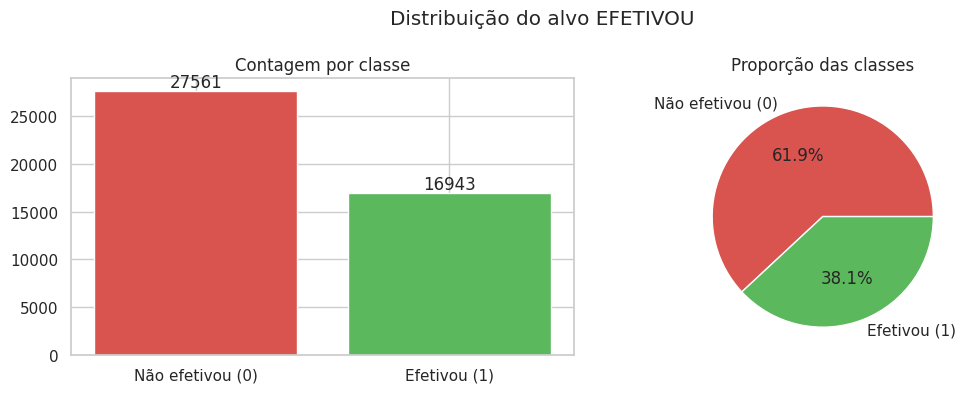

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = base["EFETIVOU"].value_counts().sort_index()
labels = ["Não efetivou (0)", "Efetivou (1)"]
ax[0].bar(labels, counts.values, color=["#d9534f", "#5cb85c"])
ax[0].set_title("Contagem por classe")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom")
ax[1].pie(counts.values, labels=labels, autopct="%1.1f%%", colors=["#d9534f", "#5cb85c"])
ax[1].set_title("Proporção das classes")
plt.suptitle("Distribuição do alvo EFETIVOU")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda1_alvo.png", dpi=110, bbox_inches="tight"); plt.show()

### 1.5 Visualização 2 — Distribuição das notas por classe

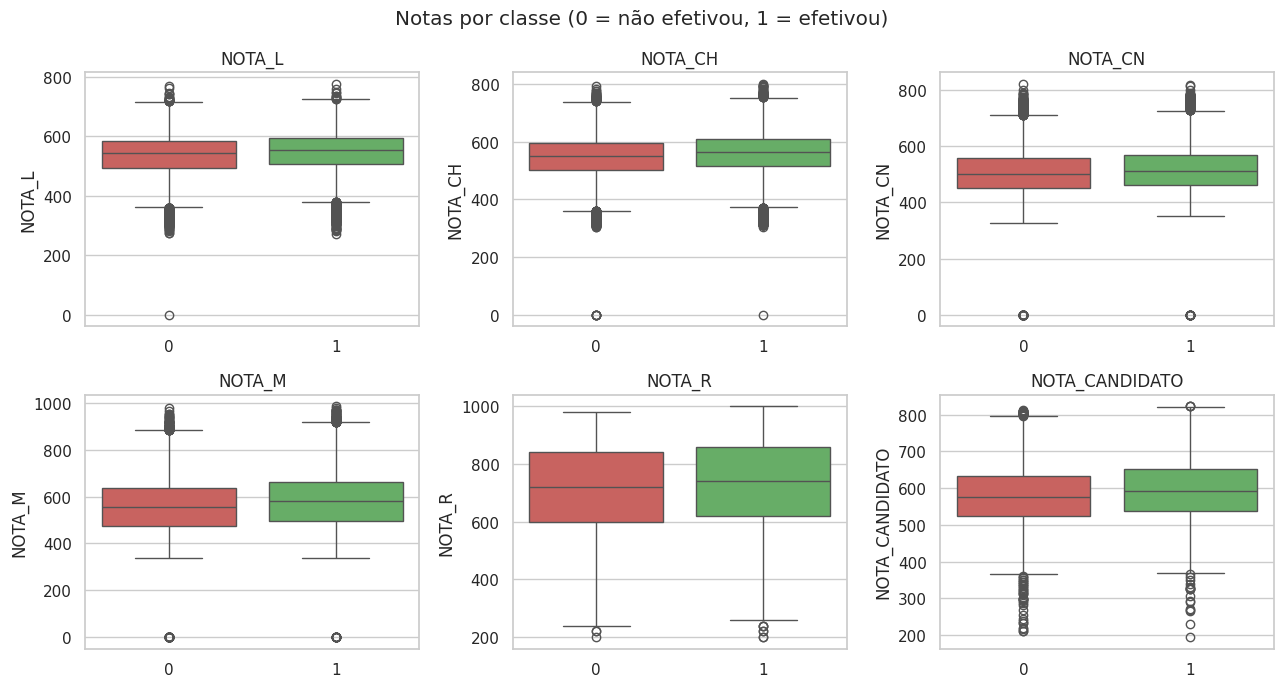

In [21]:
notas = ["NOTA_L", "NOTA_CH", "NOTA_CN", "NOTA_M", "NOTA_R", "NOTA_CANDIDATO"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), notas):
    sns.boxplot(data=base, x="EFETIVOU", y=col, ax=ax, palette=["#d9534f", "#5cb85c"])
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Notas por classe (0 = não efetivou, 1 = efetivou)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda2_notas.png", dpi=110, bbox_inches="tight"); plt.show()

### 1.6 Visualização 3 — Mapa de correlação (numéricas)

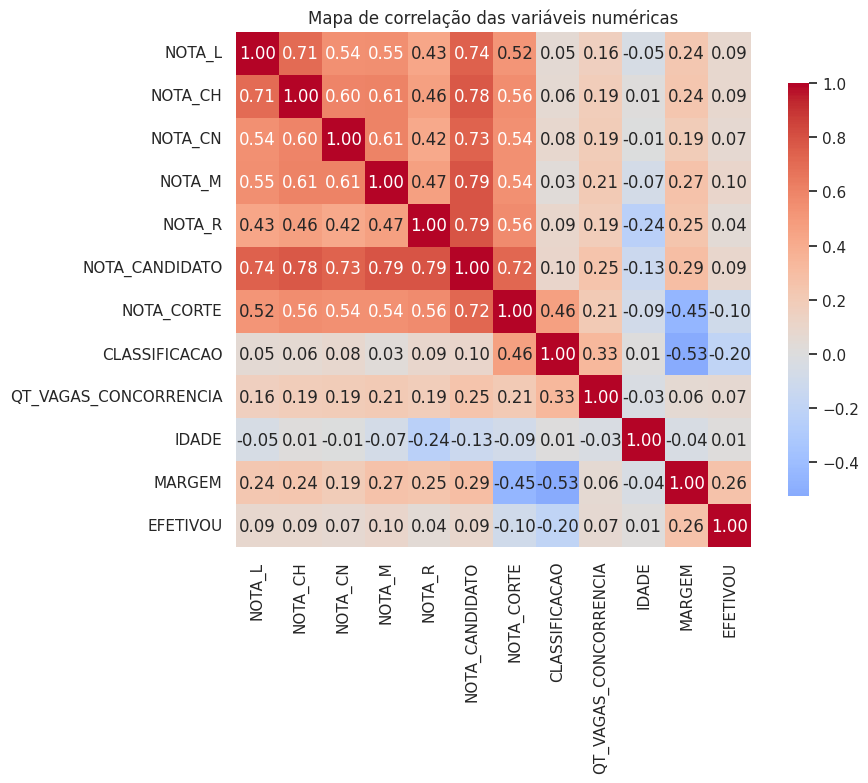

In [22]:
num_cols = ["NOTA_L","NOTA_CH","NOTA_CN","NOTA_M","NOTA_R","NOTA_CANDIDATO",
            "NOTA_CORTE","CLASSIFICACAO","QT_VAGAS_CONCORRENCIA","IDADE","MARGEM","EFETIVOU"]
plt.figure(figsize=(10, 8))
sns.heatmap(base[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Mapa de correlação das variáveis numéricas")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda3_corr.png", dpi=110, bbox_inches="tight"); plt.show()

### 1.7 Visualização 4 — Dimensão geográfica (UF e MESMA_UF)

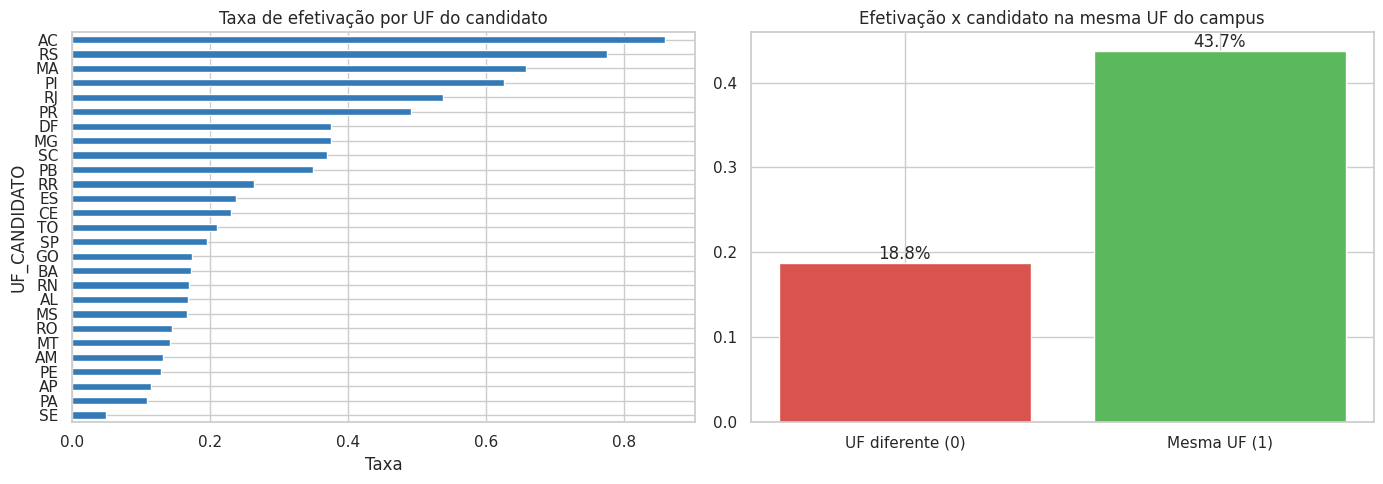

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
uf_rate = base.groupby("UF_CANDIDATO")["EFETIVOU"].mean().sort_values()
uf_rate.plot(kind="barh", ax=ax[0], color="#337ab7")
ax[0].set_title("Taxa de efetivação por UF do candidato"); ax[0].set_xlabel("Taxa")
mesma = base.groupby("MESMA_UF")["EFETIVOU"].mean()
ax[1].bar(["UF diferente (0)", "Mesma UF (1)"], mesma.values, color=["#d9534f", "#5cb85c"])
ax[1].set_title("Efetivação x candidato na mesma UF do campus")
for i, v in enumerate(mesma.values):
    ax[1].text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda4_geo.png", dpi=110, bbox_inches="tight"); plt.show()

### 1.8 Visualização 5 — Taxa de efetivação por variáveis categóricas

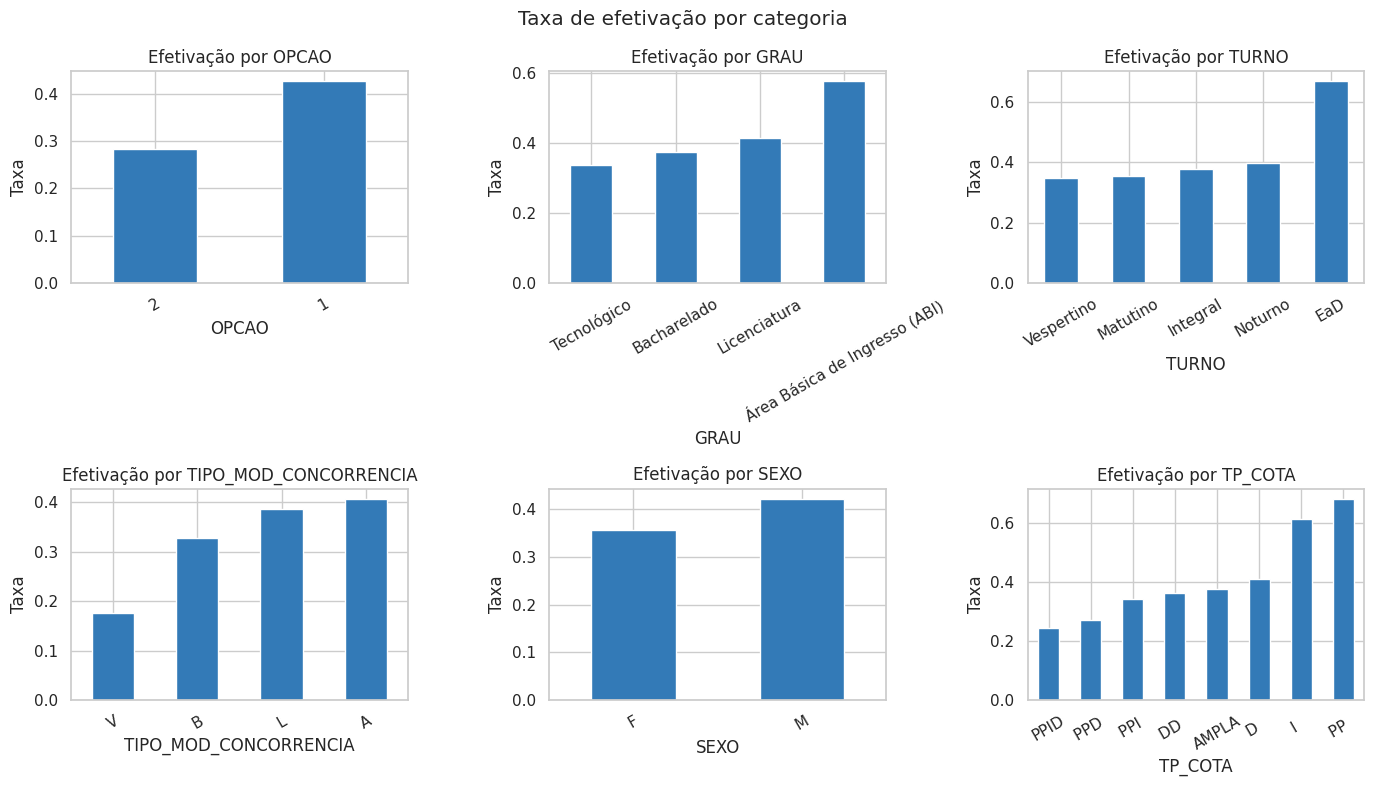

In [24]:
tmp = base.copy()
tmp["TP_COTA"] = tmp["TP_COTA"].fillna("AMPLA")
cats = ["OPCAO", "GRAU", "TURNO", "TIPO_MOD_CONCORRENCIA", "SEXO", "TP_COTA"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cats):
    r = tmp.groupby(col)["EFETIVOU"].mean().sort_values()
    r.plot(kind="bar", ax=ax, color="#337ab7")
    ax.set_title(f"Efetivação por {col}"); ax.set_ylabel("Taxa")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Taxa de efetivação por categoria")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda5_categoricas.png", dpi=110, bbox_inches="tight"); plt.show()

### 1.9 Visualização 6 — Outliers (boxplots) e quantificação por IQR

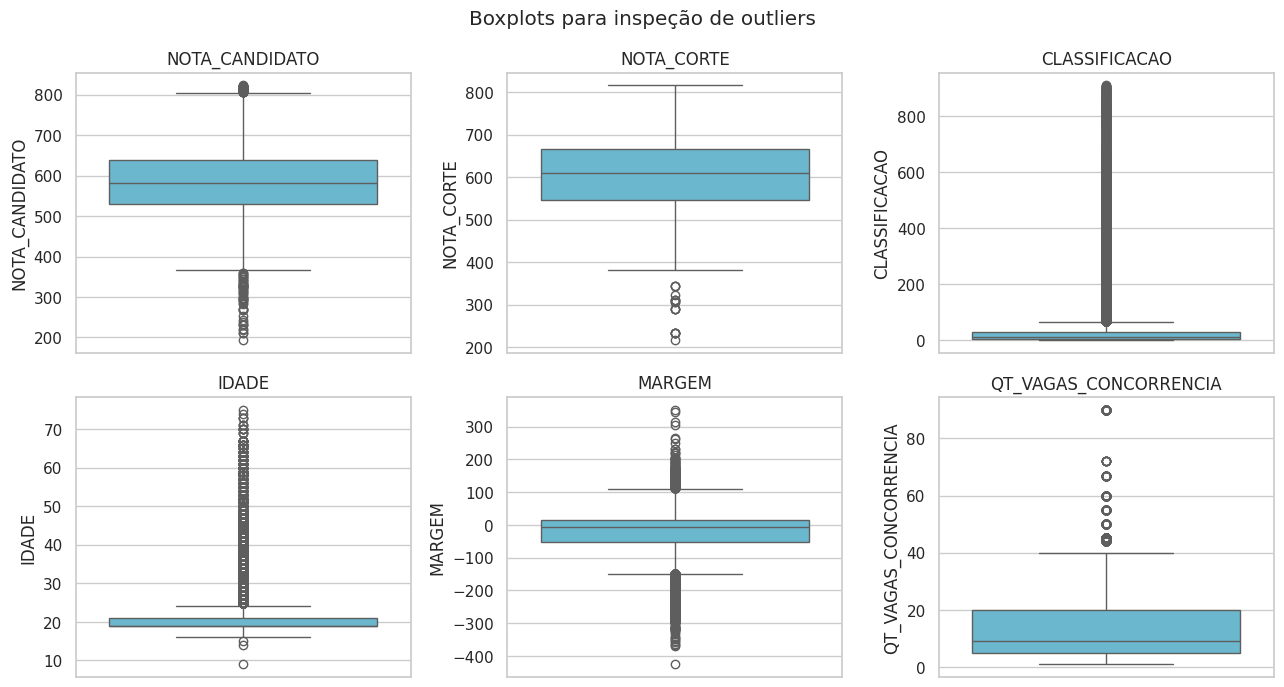

Outliers pela regra 1.5*IQR:
          NOTA_CANDIDATO:    130 ( 0.3%)  limites=[362.6, 805.7]
              NOTA_CORTE:     19 ( 0.0%)  limites=[367.9, 844.8]
           CLASSIFICACAO:   5120 (11.5%)  limites=[-33.5, 66.5]
                   IDADE:   5728 (12.9%)  limites=[16.0, 24.0]
                  MARGEM:   2046 ( 4.6%)  limites=[-148.6, 111.4]
   QT_VAGAS_CONCORRENCIA:   1238 ( 2.8%)  limites=[-17.5, 42.5]


In [25]:
out_cols = ["NOTA_CANDIDATO", "NOTA_CORTE", "CLASSIFICACAO", "IDADE", "MARGEM", "QT_VAGAS_CONCORRENCIA"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), out_cols):
    sns.boxplot(y=base[col], ax=ax, color="#5bc0de"); ax.set_title(col)
plt.suptitle("Boxplots para inspeção de outliers")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/eda6_outliers.png", dpi=110, bbox_inches="tight"); plt.show()

print("Outliers pela regra 1.5*IQR:")
for col in out_cols:
    q1, q3 = base[col].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((base[col] < lo) | (base[col] > hi)).sum())
    print(f"  {col:>22}: {n:6d} ({100*n/len(base):4.1f}%)  limites=[{lo:.1f}, {hi:.1f}]")

### 1.10 Síntese da EDA e decisões de pré-processamento

**Achados principais**
- População do Problema B: **44.504** convocados resolvidos; alvo `EFETIVOU` com **38,1% positivos** (moderadamente desbalanceado).
- Sinais preditivos fortes e **contextuais**: `MESMA_UF` (43,7% vs 18,8%), `OPCAO` (1ª 43% vs 2ª 28%), `TP_COTA`, `GRAU`, `SEXO`. As notas absolutas têm correlação linear fraca com o alvo.
- **Multicolinearidade**: as 5 notas por área são redundantes com `NOTA_CANDIDATO` (r≈0,74–0,78).
- **Outliers** majoritariamente legítimos (idade alta, posição alta na lista, notas baixas reais).

**Decisões (CP-A / CP-B):**
1. **Outliers:** manter (são legítimos) e usar **RobustScaler** (mediana/IQR) para reduzir sensibilidade em KNN/SVM.
2. **Redundância:** descartar as 5 notas por área; manter o resumo `NOTA_CANDIDATO` + contexto.
3. **Encoding:** **One-Hot** uniforme para as nominais (não impõe ordem falsa; um único conjunto de features → comparação justa entre os 6 modelos).
4. **Faltantes:** `TP_COTA` NaN → categoria `"AMPLA"` (ampla/sem cota); `NOTA_CORTE` e `MARGEM` → imputação por **mediana dentro do pipeline** (sem vazamento, ajustada só no treino); `PERCENTUAL_BONUS` descartada (94,7% ausente).